In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Tema 1 escolhido
df = pd.read_csv('retail_fraud_detection_100k.csv')

display(df.head())

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
0,T0000001,C20953,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,...,4,1054,0,0,0,1,0,1,0,Medium
1,T0000002,C24133,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,...,2,97,0,0,0,0,0,0,0,Low
2,T0000003,C07165,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,...,4,779,1,0,0,0,0,0,0,Medium
3,T0000004,C19310,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,...,3,286,1,1,0,1,0,1,1,High
4,T0000005,C25019,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,...,3,866,0,0,0,1,0,0,0,Low


Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   transaction_id                    100000 non-null  object 
 1   customer_id                       100000 non-null  object 
 2   transaction_timestamp             100000 non-null  object 
 3   transaction_amount                100000 non-null  float64
 4   payment_method                    100000 non-null  object 
 5   device_type                       100000 non-null  object 
 6   location                          100000 non-null  object 
 7   merchant_category                 100000 non-null  object 
 8   is_international                  100000 non-null  int64  
 9   transaction_frequency_24h         100000 non-null  int64  
 10  avg_transaction_amount_7d         100000 non-null  float64
 11  failed_transaction_count_24h 

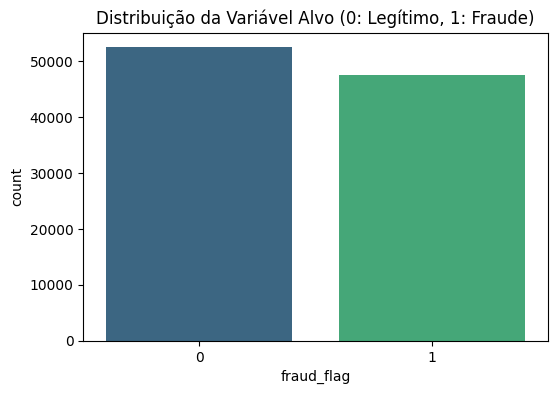


Contagem de classes:
fraud_flag
0    52.492
1    47.508
Name: proportion, dtype: float64


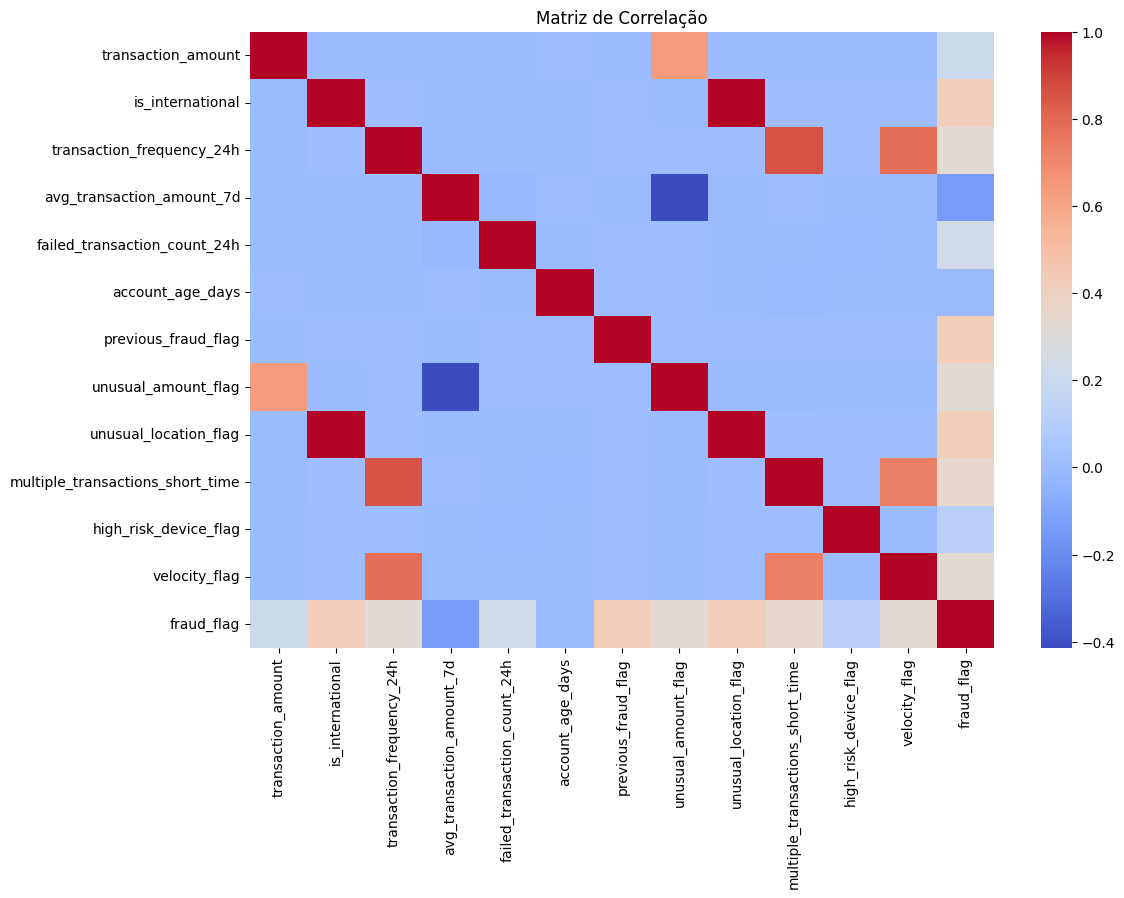

In [20]:
# Análise Exploratória (EDA)
print("Informações do Dataset:")
df.info()

print("\nValores Nulos por Coluna:")
print(df.isnull().sum())

# Distribuição da Variável Alvo (Desequilíbrio de classes)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='fraud_flag', palette='viridis')
plt.title('Distribuição da Variável Alvo (0: Legítimo, 1: Fraude)')
plt.show()

print("\nContagem de classes:")
print(df['fraud_flag'].value_counts(normalize=True) * 100)

# Matriz de Correlação
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

In [21]:
# Pré-processamento

# Remoção de colunas identificadoras e timestamp e tratamento de vazamento de dados
colunas_para_remover = [
    'transaction_id', 'customer_id', 'transaction_timestamp', 'fraud_risk',
    'unusual_amount_flag', 'unusual_location_flag', 'previous_fraud_flag',
    'multiple_transactions_short_time', 'velocity_flag', 'high_risk_device_flag'
]
df_clean = df.drop(columns=colunas_para_remover)

# Tratamento de Variáveis Categóricas
categorical_cols = df_clean.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

X = df_clean.drop('fraud_flag', axis=1)
y = df_clean['fraud_flag']

# Divisão em treino e teste (estratificado devido ao desbalanceamento)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Normalização/Escalonamento dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Tamanho do treino: {X_train_scaled.shape[0]} amostras")
print(f"Tamanho do teste: {X_test_scaled.shape[0]} amostras")

Tamanho do treino: 70000 amostras
Tamanho do teste: 30000 amostras


Modelo: Logistic Regression
ROC-AUC: 0.8717
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.78      0.79     15748
           1       0.76      0.78      0.77     14252

    accuracy                           0.78     30000
   macro avg       0.78      0.78      0.78     30000
weighted avg       0.78      0.78      0.78     30000



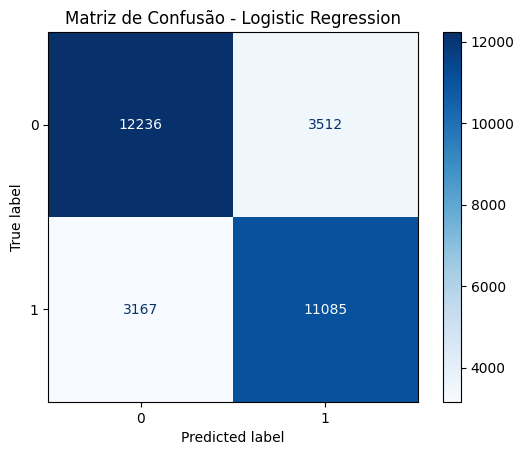



Modelo: Random Forest
ROC-AUC: 0.9039
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79     15748
           1       0.77      0.79      0.78     14252

    accuracy                           0.78     30000
   macro avg       0.78      0.78      0.78     30000
weighted avg       0.78      0.78      0.78     30000



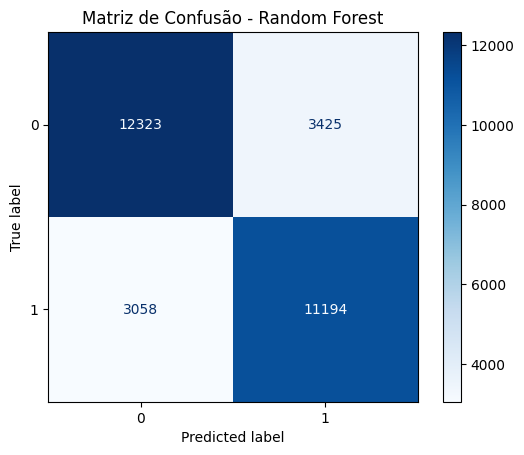



Modelo: XGBoost
ROC-AUC: 0.9061
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79     15748
           1       0.75      0.83      0.79     14252

    accuracy                           0.79     30000
   macro avg       0.79      0.79      0.79     30000
weighted avg       0.79      0.79      0.79     30000



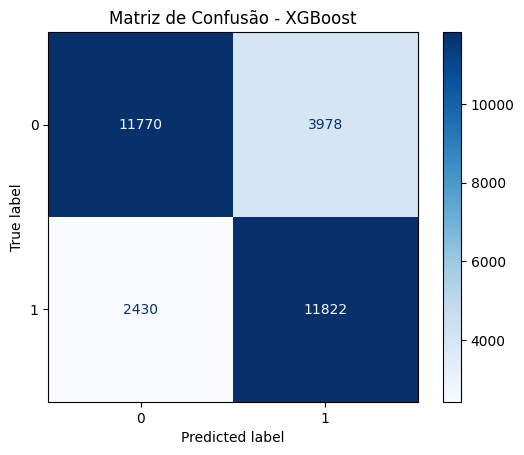

In [22]:
# Treinamento e Avaliação (Modelos Supervisionados)

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train), random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Modelo: {name}")
    # Treinamento
    model.fit(X_train_scaled, y_train)

    # Previsões
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Métricas
    roc_auc = roc_auc_score(y_test, y_proba)
    results[name] = roc_auc

    print(f"ROC-AUC: {roc_auc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Matriz de Confusão
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusão - {name}')
    plt.show()
    print("\n")

Modelo Isolation Forest
Classification Report (Isolation Forest):
              precision    recall  f1-score   support

           0       0.56      0.56      0.56     15748
           1       0.51      0.52      0.52     14252

    accuracy                           0.54     30000
   macro avg       0.54      0.54      0.54     30000
weighted avg       0.54      0.54      0.54     30000



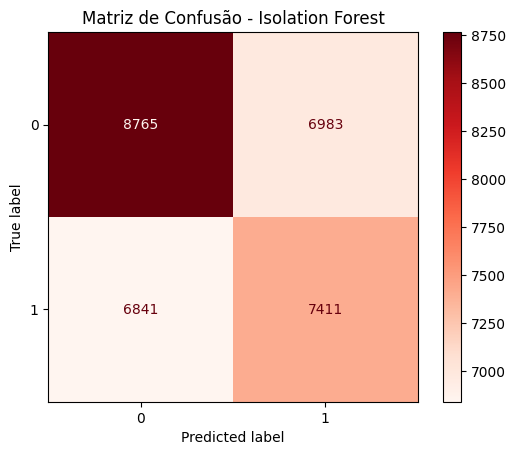

In [23]:
# Isolation Forest
print("Modelo Isolation Forest")

# O Isolation forest assume que as anomalias são raras.
# A contaminação é a proporção de fraudes no dataset.
contamination_rate = y_train.mean()

iso_forest = IsolationForest(contamination=contamination_rate, random_state=42)
iso_forest.fit(X_train_scaled)

# Previsões: -1 é anomalia (fraude), 1 é normal (legítimo)
iso_preds = iso_forest.predict(X_test_scaled)

# Mapeando de volta para 0 e 1 (1 para fraude, 0 para legítimo)
iso_preds_mapped = np.where(iso_preds == -1, 1, 0)

print("Classification Report (Isolation Forest):")
print(classification_report(y_test, iso_preds_mapped))

cm_iso = confusion_matrix(y_test, iso_preds_mapped)
disp_iso = ConfusionMatrixDisplay(confusion_matrix=cm_iso, display_labels=[0, 1])
disp_iso.plot(cmap='Reds')
plt.title('Matriz de Confusão - Isolation Forest')
plt.show()

**Discussão e Conclusão dos Resultados:**

Para garantir um cenário realista e evitar Data Leakage (vazamento de dados), as variáveis indicadoras pré-calculadas foram removidas, forçando os modelos a encontrarem padrões nos dados brutos das transações.

Modelos Supervisionados: O XGBoost obteve o melhor desempenho geral, alcançando o maior ROC-AUC (0.9061) e o melhor Recall para a classe de fraude (0.83). Ele superou o Random Forest e a Regressão Logística na tarefa crítica de identificar o máximo de fraudes possíveis sem penalizar excessivamente clientes legítimos.

Modelo Não Supervisionado: O Isolation Forest apresentou desempenho inferior na classificação direta. Como ele foca em detectar anomalias gerais, acaba gerando muitos falsos positivos, já que nem todo comportamento atípico é necessariamente uma fraude.

Veredito: O **XGBoost** é o modelo mais adequado para este problema. No contexto do varejo, onde o custo de chargebacks é alto, sua capacidade superior de prever fraudes reais o torna ideal para implementação em produção.